# Part 1: Checking for quality issues

For this first part I want to check if data is missing, broken or suspicious.

The following includes the attributes within the reviews dataset which shouldn't be null: user_id, name, time, rating, gmap_id
The following includes the attributes within the business dataset (metadata) which shouldn't be null: name, address, gmap_id, category, avg_rating, num_of_reviews
* Are any of these attributes null at any point?
* Do we have duplicate entries in our data or metadata?
* Is every Google Map ID within the reviews dataset included within the business dataset?

First, let's see if any of the crucial attributes are null.

In [1]:
import sys
import pandas as pd

# open the JSON files
try:
    rd1 = pd.read_json('data/review-Georgia.json', lines=True, chunksize=1000)
    rd2 = pd.read_json('data/meta-Georgia.json', lines=True)
except FileNotFoundError:
    print("File not found")
    sys.exit()

#non-null attribute list
nnal = [0, 0, 0, 0, 0]
# append set in chunks for both data and metadata
for chunk in rd1:
    nnal[0] += chunk['user_id'].isnull().sum()
    nnal[1] += chunk['name'].isnull().sum()
    nnal[2] += chunk['time'].isnull().sum()
    nnal[3] += chunk['rating'].isnull().sum()
    nnal[4] += chunk['gmap_id'].isnull().sum()
print("Review data:")
#attribute name list
anl = ["user_id", "name", "time", "rating", "gmap_id"]
for i in range(len(nnal)):
    print("Number of " + anl[i] + " that is null: " + str(nnal[i]))

print("Metadata:")
nnal = [0, 0, 0, 0, 0, 0]
anl = ["name", "address", "gmap_id", "category", "avg_rating", "num_of_reviews"]
nnal[0] = rd2['name'].isnull().sum()
nnal[1] = rd2['address'].isnull().sum()
nnal[2] = rd2['gmap_id'].isnull().sum()
nnal[3] = rd2['category'].isnull().sum()
nnal[4] = rd2['avg_rating'].isnull().sum()
nnal[5] = rd2['num_of_reviews'].isnull().sum()
for i in range(len(nnal)):
    print("Number of " + anl[i] + " that is null: " + str(nnal[i]))


Number of user_id that is null: 167543
Number of name that is null: 0
Number of time that is null: 0
Number of rating that is null: 167543
Number of gmap_id that is null: 0
Number of name that is null: 1
Number of address that is null: 3501
Number of gmap_id that is null: 0
Number of category that is null: 763
Number of avg_rating that is null: 0
Number of num_of_reviews that is null: 0


The same number of user_id and ratings are null. This indicates that some type of reviewer without a user_id is posting reviews that are null. In addition, there are null entries within almost all values in the metadata. Let's investigate further:
From a surface-level look, I found a case where the user_id is null has the name labeled as "Expedia reviewer". This says that there are reviews within the dataset which are imported from other review platforms, such as Expedia. Let's see if this applies to all cases. If this next script returns a small number, then we can tell that these cases are exclusively from reviews from other platforms.

In [5]:
import sys
import pandas as pd

# open the JSON file
try:
    data = pd.read_json('data/review-Georgia.json', lines=True, chunksize=100000)
except FileNotFoundError:
    print("File not found")
    sys.exit()

name_lists = set()
for chunk in data:
    missing_users = chunk[chunk['user_id'].isnull()]
    name_lists.update(missing_users['name'])

print(len(name_lists))
with open("data/names_of_nonids.txt", "w", encoding="utf-8") as f:
    for item in name_lists:
        try:
            f.write(f"{item}\n")
        except UnicodeEncodeError:
            print("UnicodeEncodeError: for type " + type(item))

54863


54,863 reviewers. After looking into the .txt file returned, I discovered that there are in fact legitimate users mixed into this. After searching manually, I found:
* There were a substantial amount of reviews in the dataset from other applications (Expedia, Hotels.com)
* There existed reviews from normal names.
* The reviews posted appeared to be completely legitimate
* The time of the reviews posted ended with 5 (or more) 0's, but still could vary in timing. 100 seconds isn't that large an interval, but it does indicate timing inaccurate to when the reviews were actually posted.

I could manually assign them a custom user_id, but reviews that they give have no number. Since this only takes up 54,863/24,060,125 = 0.228% of the reviewers and 0.696% of the total reviews, I will drop them.

In [ ]:
import sys
import pandas as pd

# open the JSON files
try:
    rd1 = pd.read_json('data/review-Georgia.json', lines=True, chunksize=1000)
    rd2 = pd.read_json('data/meta-Georgia.json', lines=True, chunksize=1000)
except FileNotFoundError:
    print("File not found")
    sys.exit()

# Check for corresponding gmap_ids
# set up sets because we don't need to worry about duplicates... yet
gmap_id_dset = set()
gmap_id_mset = set()
# append set in chunks for both data and metadata
for chunk in rd1:
    gmap_id_dset|=set(chunk['gmap_id'])
for chunk in rd2:
    gmap_id_mset|=set(chunk['gmap_id'])
# check for gmap_id in data with no corresponding gmap_id in metadata
missing_list = gmap_id_dset - gmap_id_mset
if len(missing_list) > 0:
    print("Missing gmap_ids found:")
    print(list(missing_list))
else:
    print("There are no missing gmap_ids")

This confirms that there are no missing gmap_ids.

Now to check for duplicates. Since I am limited on memory usage, I will choose a select few variables to determine if a member of the dataset is a duplicate. I decided to count any part of the metadata with the same Name, Address, and gmap_id as a duplicate.

In [2]:
import sys
import pandas as pd

# open the JSON file
try:
    rd2 = pd.read_json('data/meta-Georgia.json', lines=True)
except FileNotFoundError:
    print("File not found")
    sys.exit()

# just get the number of duplicated rows.
print("Number of duplicated rows in metadata:")
print(rd2.duplicated(subset=['name', 'address', 'gmap_id']).sum())


Number of duplicated rows in metadata:
986


This confirms that there are duplicate entries. I'll remove duplicate entries after finding the number within the reviews dataset.

This will have to be done differently as I do not have enough RAM to have the full file open. As a result, I shall open the dataset in chunks. This disallows accurate usage of data.duplicated.sum, forcing me to store the attributes in a set.

In [3]:
import sys
import pandas as pd
# this is more complicated than the last script
duplicate_count = 0
try:
    # make a set (a data type that can't have duplicates)
    keys_seen = set()
    # open the data file in chunks of 1000
    data = pd.read_json('data/review-Georgia.json', lines=True, chunksize=1000)
    for chunk in data:
        # zip allows for parallel iteration, allowing for us to speed up this process
        keys = zip(chunk['user_id'], chunk['time'], chunk['gmap_id'])
        for key in keys:
            if key in keys_seen:
                duplicate_count += 1
            else:
                keys_seen.add(key)
except FileNotFoundError:
    print("File not found")
    sys.exit()

print("Number of duplicated rows in data:")
print(duplicate_count)


Number of duplicated rows in metadata:
322360


This confirms a significant number of duplicates within the dataset. Now to remove these duplicates.

# Part 2: Complete transformation

The objectives of these two scripts are to:
* Remove duplicates and useless labels
* Replace the pics with the number of pictures
* Place the new .json file within the data folder


In [1]:
import pandas as pd
try:
    rd1 = pd.read_json('data/meta-Georgia.json', lines=True)
    rd1.drop(labels=['description', 'price', 'MISC', 'state', 'relative_results', 'url'], axis=1, inplace=True)
    # drop duplicates from file
    rd1.drop_duplicates(subset=['name', 'address', 'gmap_id'], inplace=True)
    # return cleaned file
    rd1.to_json('data/meta-Georgia_cleaned.json', orient='records', lines=True)
except FileNotFoundError:
    print("File not found")

This reduced the size of the metadata file by 74.39%

In [6]:
import pandas as pd
import numpy as np
keys_seen = set()
boolean_mask = []
try:
    data = pd.read_json('data/review-Georgia.json', lines=True, chunksize=1000, dtype={'user_id':str, 'text':str, 'gmap_id':str})
    for chunk in data:
        # drop null user_ids and ratings from chunk
        chunk = chunk.dropna(subset=['user_id', 'rating'])
        # change pics into number of pics
        chunk['pics'] = chunk['pics'].apply(lambda x: len(x) if isinstance(x, list) else 0)
        # change text into word_count
        chunk['word_count'] = chunk['text'].fillna("").str.split().str.len().astype(np.uint32)
        keys = chunk[['user_id', 'time', 'gmap_id']].itertuples(index=False, name=None)
        for key in keys:
            if key in keys_seen:
                boolean_mask.append(False)
            else:
                boolean_mask.append(True)
                keys_seen.add(key)
        # drops the label last so I can utilize text
        chunk.drop(labels=['name', 'resp', 'text'], axis=1, inplace=True)
        chunk[boolean_mask].to_json('data/review-Georgia_cleaned.json', orient='records', lines=True, mode='a')
        #reset boolean mask's value
        boolean_mask = []
except FileNotFoundError:
    print("File not found")
except Exception as e:
    print(e)

This reduced the size of the data file by 56.5%

# Part 3: EDA
Next, I need to do basic analysis of the variables listed in the cleaned .json files.



In [1]:
import pandas as pd
try:
    print("Metadata Statistics")
    df = pd.read_json('data/meta-Georgia_cleaned.json', lines=True)
    print(df.describe())

except FileNotFoundError:
    print("File not found")

Metadata Statistics
            latitude      longitude     avg_rating  num_of_reviews
count  165395.000000  165395.000000  165395.000000   165395.000000
mean       33.432707     -83.858679       4.259773      145.357109
std         0.950851       2.404695       0.676245      369.566285
min        25.126484     -88.100026       1.000000        1.000000
25%        33.041988     -84.472016       4.000000        8.000000
50%        33.773949     -84.218039       4.400000       35.000000
75%        34.000048     -83.658343       4.800000      118.000000
max        42.639763     180.000000       5.000000     9998.000000


Some latitudes and longitudes are improperly entered. We can see that the minimum latitude is south of most of Florida, the maximum latitude is located in the northern U.S. The minimum longitude is west of Georgia's western border, and the maximum longitude is near the international date line.

The overwhelming majority of the average ratings are positive. The number of reviews that a particular business has ranges from 1-9998.
I had to create a version of the review data including only the variables that would be useful with df.describe.

In [7]:
import pandas as pd
import numpy as np
try:
    df = pd.read_json('data/review-Georgia_cleaned.json', lines=True, dtype={'user_id':str, 'time':np.uint64, 'rating':np.int8, 'gmap_id':str}, chunksize=10000)
    for chunk in df:
        chunk.drop(labels=['user_id', 'gmap_id'], axis=1, inplace=True)
        # characteristics and ratings
        chunk.to_json('data/review-Georgia_CandR.json', orient='records', lines=True, mode='a')
except FileNotFoundError:
    print("File not found")

In [8]:
import pandas as pd
import numpy as np
try:
    df = pd.read_json('data/review-Georgia_CandR.json', lines=True, dtype={'time':np.uint64, 'rating':np.int8, 'pics':np.uint8})
    # no pandas I don't want this in scientific notation
    pd.set_option('display.float_format', lambda x: f'{x:.2f}')
    print(df.describe())
except FileNotFoundError:
    print("File not found")


                  time      rating        pics  word_count
count      23570222.00 23570222.00 23570222.00 23570222.00
mean  1551894711833.22        4.23        0.06       17.17
std     44138811880.72        1.24        0.73       38.05
min    978739200000.00        1.00        0.00        0.00
25%   1523963201185.50        4.00        0.00        0.00
50%   1555369870453.00        5.00        0.00        4.00
75%   1582724181814.50        5.00        0.00       18.00
max   1631158941334.00        5.00       50.00     2109.00


I saw RAM usage go up to almost 15GB while running this script.
Next, let's make a histogram to get a better visual.

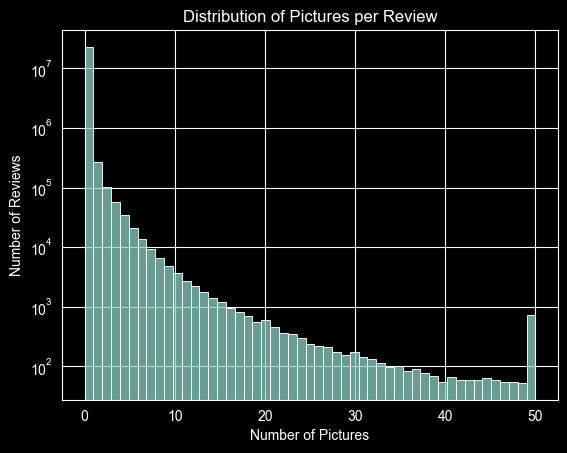

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_json('data/review-Georgia_CandR.json', lines=True, dtype={'time':np.uint64, 'rating':np.int8, 'pics':np.uint8})
    # we use bins = 51 since we now that we have 0-50 pictures in the reviews.
    plot = sns.histplot(df['pics'], bins=51)
    plt.xlabel("Number of Pictures")
    plt.ylabel("Number of Reviews")
    plt.title("Distribution of Pictures per Review")
    #using logarithmic scale because we would not be able to see anything.
    plot.set_yscale('log')
    plt.show()
except FileNotFoundError:
    print("File not found")

This is certainly interesting. We have a steady decline in the number of pictures in reviews up until we reach 50. I think that from this graph we have found people who post the most pictures they can per review.
# Part 3: Discovery Questions Regarding Users
I will now proceed to alter the cleaned data (not CandR) to group by users in order to answer discovery questions regarding them. Of all the scripts, this takes the longest to complete. I've observed that it takes between 30 minutes and a full hour to complete.

In [1]:
import pandas as pd
import numpy as np

def compute_diff(t):
    if len(t) <= 1:
        return 0
    st = np.diff(sorted(t))
    if np.mean(st) == 0:
        return 0
    return np.std(st)/np.mean(st)

try:
    # create a data structure that will contain the user_ids (and other info) to add to the rgur_data.json file called data
    data = pd.DataFrame()
    chunk_count = 1
    df = pd.read_json('data/review-Georgia_cleaned.json', lines=True, dtype={'user_id':str, 'time':np.uint64, 'rating':np.int8, 'pics':np.uint8, 'word_count':np.uint16, 'gmap_id':str}, chunksize=1000000)
    for chunk in df:
        print("We have reached chunk " + str(chunk_count))
        chunk_count += 1
        grouped = chunk.groupby('user_id').agg(
            total_pictures=('pics','sum'),
            max_pics=('pics', 'max'),
            total_reviews=('pics', 'count'),
            rev_with_pics=('pics', lambda x: (x>0).sum()),
            total_words=('word_count', 'sum'),
            max_words=('word_count', 'max'),
            rev_with_words=('word_count', lambda x: (x>0).sum()),
            review_times=('time', list),
            ratings=('rating', list),
        )
        if data.empty:
            data = grouped
        else:
            # this line is to add values (excluding max_pics, because then we will get an incorrect max_pics)
            data[['total_pictures','total_reviews','rev_with_pics', 'total_words', 'rev_with_words']] = \
        data[['total_pictures','total_reviews','rev_with_pics','total_words', 'rev_with_words']].add(
            grouped[['total_pictures','total_reviews','rev_with_pics', 'total_words', 'rev_with_words']],
            fill_value=0
            )
            for col in ['review_times', 'ratings']:
                data[col] = data[col].combine(
                grouped[col],
                lambda x, y: (x if isinstance(x, list) else []) +
                     (y if isinstance(y, list) else [])
            )
            data['max_pics'] = np.maximum(
                data['max_pics'],
                grouped['max_pics'].reindex(data.index, fill_value=0)
            )
            data['max_words'] = np.maximum(
                data['max_words'],
                grouped['max_words'].reindex(data.index, fill_value=0)
            )
    data['avg_pictures'] = data['total_pictures'] / data['total_reviews']
    data['pics_percent'] = data['rev_with_pics'] / data['total_reviews'] * 100
    # note to self: do not sort ratings, as it is unnecessary
    data['cov_time'] = data['review_times'].map(compute_diff)
    data['cov_rating'] = data['ratings'].apply(
        lambda r: np.std(r)/np.mean(r)
    )
    data.drop(columns=['review_times', 'ratings'], inplace=True)
    # calculate avg_pictures, pics_percent in list
    # rgur stands for reviews grouped under reviewers
    data.reset_index().to_json('data/rgur_data.json', orient='records', lines=True)
    # note: this took me 12 minutes and 46 seconds for the program to run initially, but this edit to also include word data expanded that time to 37 minutes and 51 seconds
except FileNotFoundError:
    print("File not found")

We have reached chunk 1
We have reached chunk 2
We have reached chunk 3
We have reached chunk 4
We have reached chunk 5
We have reached chunk 6
We have reached chunk 7
We have reached chunk 8
We have reached chunk 9
We have reached chunk 10
We have reached chunk 11
We have reached chunk 12
We have reached chunk 13
We have reached chunk 14
We have reached chunk 15
We have reached chunk 16
We have reached chunk 17
We have reached chunk 18
We have reached chunk 19
We have reached chunk 20
We have reached chunk 21
We have reached chunk 22
We have reached chunk 23
We have reached chunk 24
We have reached chunk 1


This code above creates another JSON file with the following attributes:

* user_id: the user_id
* total_pictures: the cumulative number of pictures in all reviews posted
* max_pics: the largest number of pictures the user posted in one review
* total_reviews: the number of reviews posted by the user
* rev_with_pics: the number of reviews posted by the user with more than 0 pictures attached
* avg_pictures: the average number of pictures this user includes per review.
* pics_percent: the percentage of reviews posted by the user with more than 0 pictures attached

In [1]:
import pandas as pd
try:
    # consider chunks?
    data = pd.read_json('data/rgur_data.json', lines=True)
    data.drop(columns=['user_id'], inplace=True)
    pd.set_option('display.float_format', lambda x: f'{x:.2f}')
    print(data.describe())
except FileNotFoundError:
    print("File not found")

       total_pictures  max_pics  total_reviews  rev_with_pics  total_words  \
count       820747.00 820747.00      820747.00      820747.00    820747.00   
mean             0.79      0.29          10.92           0.27       172.14   
std             11.47      1.78          26.29           2.25       481.45   
min              0.00      0.00           1.00           0.00         0.00   
25%              0.00      0.00           1.00           0.00        13.00   
50%              0.00      0.00           2.00           0.00        50.00   
75%              0.00      0.00           7.00           0.00       148.00   
max           2175.00     50.00        1520.00         311.00     43512.00   

       max_words  rev_with_words  avg_pictures  pics_percent  cov_time  \
count  820747.00       820747.00     820747.00     820747.00 820747.00   
mean       57.17            6.37          0.04          1.50      0.73   
std        77.75           17.40          0.34          8.55      1.08   
m

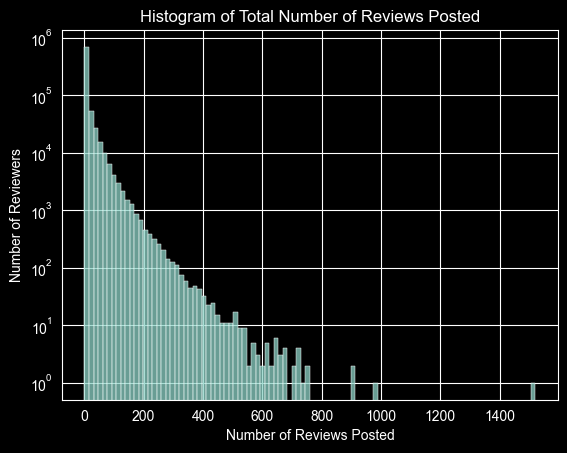

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_json('data/rgur_data.json', lines=True, dtype={'total_reviews':np.uint16})
    # we use bins = 51 since we now that we have 0-50 pictures in the reviews.
    plot = sns.histplot(df['total_reviews'], bins=100)
    plt.xlabel("Number of Reviews Posted")
    plt.ylabel("Number of Reviewers")
    plt.title("Histogram of Total Number of Reviews Posted")
    #using logarithmic scale because we would not be able to see anything.
    plot.set_yscale('log')
    plt.show()
except FileNotFoundError:
    print("File not found")

As we can see, User_ID 108416619844777498346 (the one who posted 1,520 reviews) is a complete anomaly within this list, posing 50% more reviews than the next highest reviewer. None of his reviews within this dataset have any pictures. This will be useful for me because this is a clear example of an anomaly.

Now to try to finish up this project. I need to create one JSON file with these attributes:
* the user id (primary key)
* standard deviation of inter_review times
* average number of pictures posted in reviews
* maximum number of pictures posted in reviews
* average word count in reviews
* standard deviation of ratings (for the rating patterns part)

In addition, I wish to create a second JSON file with these attributes:
* Google Maps ID
* Review count
* Number of reviews with pictures
* standard deviation of inter_review times
* Average pictures posted in reviews
* Standard deviation in ratings

Since I want word count, I will be starting from the original review file. I will remove the line that drops the label for the review.

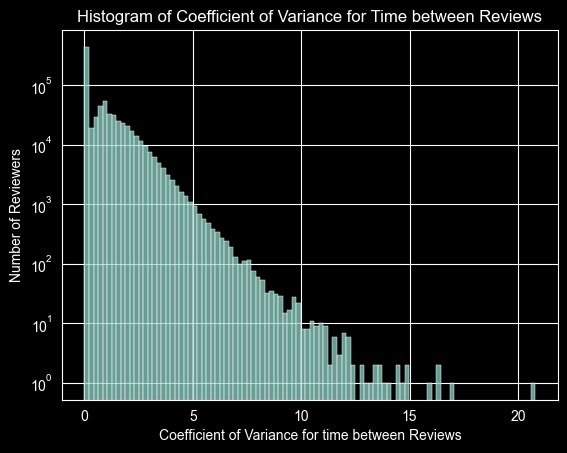

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_json('data/rgur_data.json', lines=True,)
    # we use bins = 51 since we now that we have 0-50 pictures in the reviews.
    plot = sns.histplot(df['cov_time'], bins=100)
    plt.xlabel("Coefficient of Variance for time between Reviews")
    plt.ylabel("Number of Reviewers")
    plt.title("Histogram of Coefficient of Variance for Time between Reviews")
    #using logarithmic scale because we would not be able to see anything.
    plot.set_yscale('log')
    plt.show()
except FileNotFoundError:
    print("File not found")


In order to run the DBSCAN algorithm, I must run another algorithm in order to find my epsilon.

Reading File...
Doing log transformations...
Scaling features...


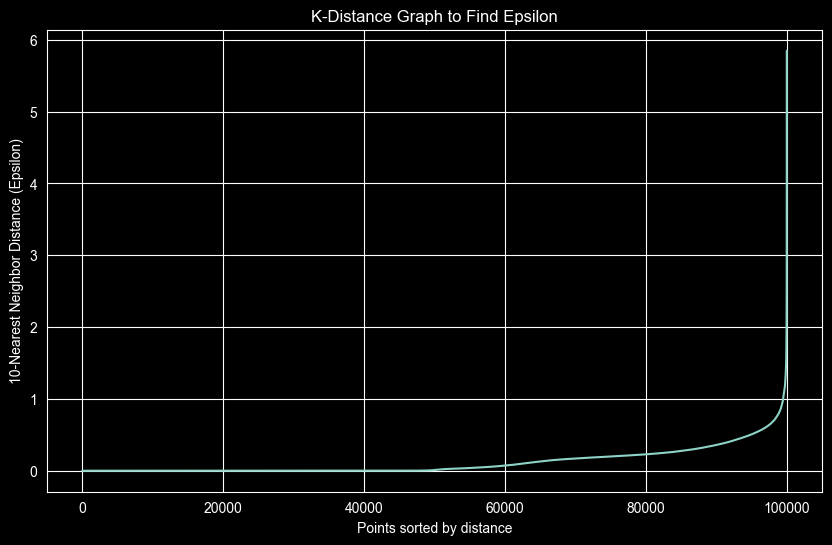

In [40]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
try:
    print("Reading File...")
    # this data is only 200 MB, so I can just read the whole thing. Using np.float16 to reduce memory usage.
    # Note, if your total word count is greater than 65536, change 'total_words':np.uint16 to 'total_words':np.uint32
    df = pd.read_json('data/rgur_data.json', lines=True, dtype={'cov_time':np.float32, 'cov_rating':np.float32, 'total_reviews':np.uint16, 'total_pictures':np.uint16, 'total_words':np.uint16}, nrows=100000)
    # keep user_id, total_pictures, total_reviews, total_words, cov_time, cov_rating
    print("Doing log transformations...")
    #doing log transformations to reduce the scale of the tail.
    df['log_reviews'] = np.log1p(df['total_reviews'], dtype=np.float32)
    df['log_pics'] = np.log1p(df['total_pictures'], dtype=np.float32)
    df['log_words'] = np.log1p(df['total_words'], dtype=np.float32)
    df.drop(columns=['max_pics', 'rev_with_pics', 'max_words', 'rev_with_words', 'avg_pictures', 'pics_percent','total_pictures', 'total_reviews', 'total_pictures'], inplace=True)
    features = df[['log_reviews', 'log_pics', 'log_words', 'cov_time', 'cov_rating']]
    # scale features
    print("Scaling features...")
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    # 1. Choose your k (min_samples)
    # Rule of thumb: min_samples = 2 * number of features
    k = 10
    # 2. Fit NearestNeighbors
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(X)
    distances, indices = nbrs.kneighbors(X)

    # 3. Sort the distances to the kth neighbor (the last column)
    distances = np.sort(distances[:, k-1], axis=0)

    # 4. Plot the distances
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.title('K-Distance Graph to Find Epsilon')
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{k}-Nearest Neighbor Distance (Epsilon)')
    plt.grid(True)
    plt.show()

except FileNotFoundError:
    print("File not found")



This gets me an epsilon of... 0.8

Scaling features...
499999.9999999927
305565.04617430107
239673.03389990845
190649.45925434228
138782.3721801896
123337.93216313735
115250.96733802216
102986.72073581701
92828.72792527569
86521.2937736337


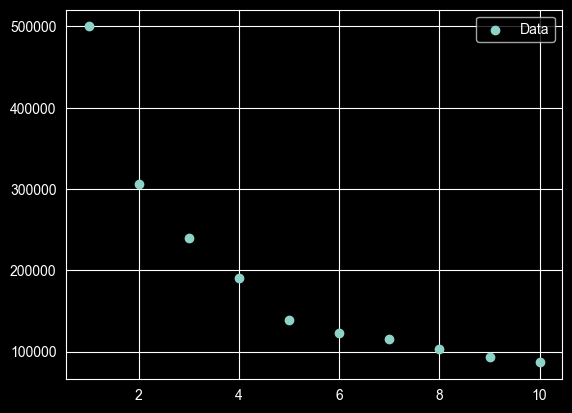

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    df = pd.read_json('data/rgur_data.json', lines=True, dtype={'user_id':str, 'cov_time':np.float32, 'cov_rating':np.float32, 'total_reviews':np.uint16, 'total_pictures':np.uint16, 'total_words':np.uint16}, nrows=100000)
    #doing log transformations to reduce the scale of the tail.
    df['log_reviews'] = np.log1p(df['total_reviews'], dtype=np.float32)
    df['log_pics'] = np.log1p(df['total_pictures'], dtype=np.float32)
    df['log_words'] = np.log1p(df['total_words'], dtype=np.float32)
    df.drop(columns=['max_pics', 'rev_with_pics', 'max_words', 'rev_with_words', 'avg_pictures', 'pics_percent','total_pictures', 'total_reviews', 'total_pictures'], inplace=True)
    features = df[['log_reviews', 'log_pics', 'log_words', 'cov_time', 'cov_rating']]
    # scale features
    print("Scaling features...")
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    #used this to detect elbow
    sse_values = []
    for k in range(1,11):
        km = KMeans(n_clusters=k)
        km.fit(X)
        sse_values.append(km.inertia_)
    for i in sse_values:
        print(i)
    x = np.zeros(len(sse_values))
    for i in range(len(sse_values)):
        x[i] = i + 1
    coefficients = np.polyfit(x, sse_values, 2)
    poly_func = np.poly1d(coefficients)




    plt.scatter(x, sse_values, label='Data')

    plt.legend()
    plt.show()
except FileNotFoundError:
    print("File not found")
except Exception as e:
    print(
        "Some other error occurred on line",
        e.__traceback__.tb_lineno,
        ":\n" + str(e)
    )

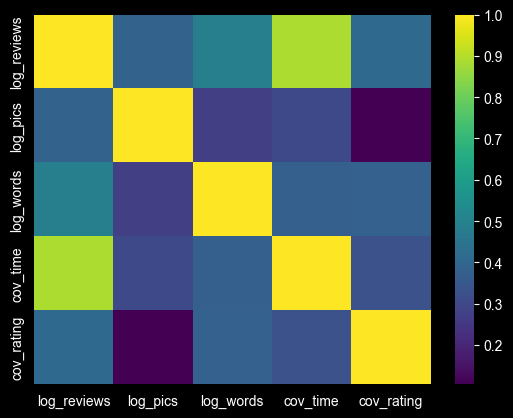

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
try:
    df = pd.read_json('data/rgur_data.json', lines=True, dtype={'user_id':str, 'cov_time':np.float32, 'cov_rating':np.float32, 'total_reviews':np.uint16, 'total_pictures':np.uint16, 'total_words':np.uint16}, nrows=100000)
    #doing log transformations to reduce the scale of the tail.
    df['log_reviews'] = np.log1p(df['total_reviews'], dtype=np.float32)
    df['log_pics'] = np.log1p(df['total_pictures'], dtype=np.float32)
    df['log_words'] = np.log1p(df['total_words'], dtype=np.float32)
    df.drop(columns=['max_pics', 'rev_with_pics', 'max_words', 'rev_with_words', 'avg_pictures', 'pics_percent','total_pictures', 'total_reviews', 'total_pictures'], inplace=True)
    features = df[['log_reviews', 'log_pics', 'log_words', 'cov_time', 'cov_rating']]
    sns.heatmap(features.corr(), cmap='viridis')
    plt.show()
except FileNotFoundError:
    print("File not found")
except Exception as e:
    print(
        "Some other error occurred on line",
        e.__traceback__.tb_lineno,
        ":\n" + str(e)
    )

Reading File...
Doing log transformations...
Scaling features...
Running DBSCAN...
Creating Scatter plot...
     log_reviews  log_pics  log_words  cov_time  cov_rating
PC1     0.565595  0.318389   0.417656  0.524937    0.358796
PC2     0.078754  0.712879  -0.206624  0.097169   -0.658382
cluster
 0    92874
 1     3864
 2     2620
-1      626
 3       16
Name: count, dtype: int64


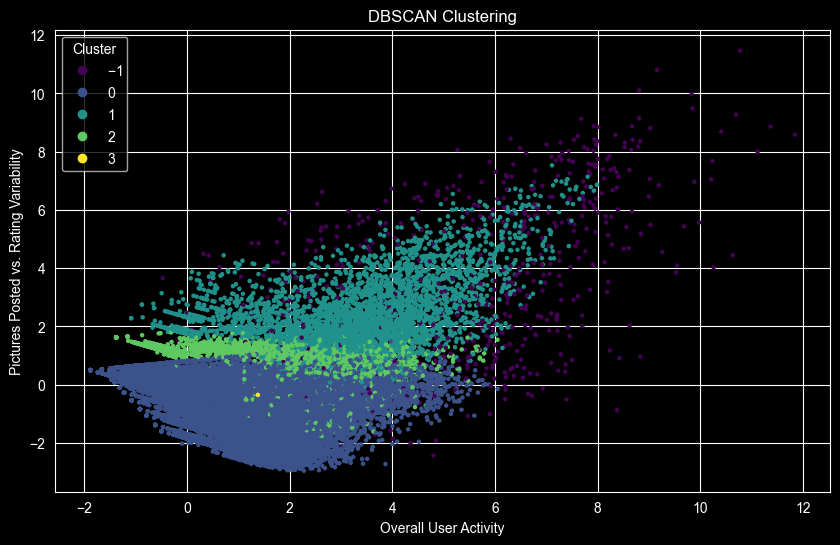

Running KMeans
Generating scatter plot...
     log_reviews  log_pics  log_words  cov_time  cov_rating
PC1     0.565595  0.318389   0.417656  0.524937    0.358796
PC2     0.078754  0.712879  -0.206624  0.097169   -0.658382
k-cluster
3    46526
0    18990
2    15707
4    14954
1     3823
Name: count, dtype: int64


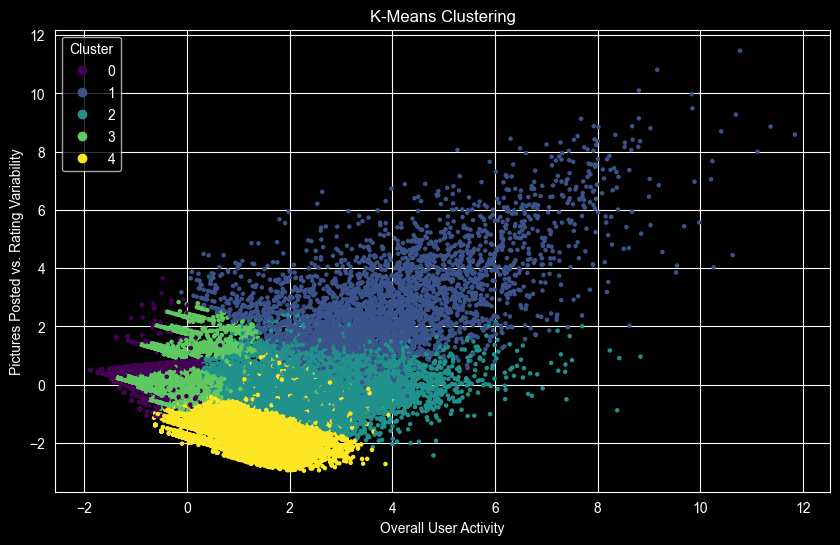

Running Isolation Forest...
Exporting clusters into datasets
For cluster  0
        total_words      cov_time    cov_rating   log_reviews  log_pics  \
count  92874.000000  92874.000000  92874.000000  92874.000000   92874.0   
mean     109.722980      0.582778      0.122465      1.432779       0.0   
std      224.855751      0.932704      0.206453      0.922626       0.0   
min        0.000000      0.000000      0.000000      0.693147       0.0   
25%       11.000000      0.000000      0.000000      0.693147       0.0   
50%       43.000000      0.000000      0.000000      1.098612       0.0   
75%      116.000000      0.962133      0.192450      1.791759       0.0   
max    10886.000000      8.345260      0.894427      6.230482       0.0   

          log_words  cluster     k-cluster  iforest_label  iforest_score  
count  92874.000000  92874.0  92874.000000   92874.000000   92874.000000  
mean       3.437266      0.0      2.390443       0.712277       0.065760  
std        1.887747    

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
try:
    print("Reading File...")
    # this data is only 200 MB, so I can just read the whole thing. Using np.float16 to reduce memory usage.
    # Note, if your total word count is greater than 65536, change 'total_words':np.uint16 to 'total_words':np.uint32
    df = pd.read_json('data/rgur_data.json', lines=True, dtype={'user_id':str, 'cov_time':np.float32, 'cov_rating':np.float32, 'total_reviews':np.uint16, 'total_pictures':np.uint16, 'total_words':np.uint16}, chunksize=100000)
    # 0 for first 100,000
    select_chunk = 0
    # keep unchanged
    current_chunk = 0
    for chunk in df:
        if current_chunk < select_chunk:
            current_chunk += 1
        else:
            used_data = chunk
            break
    try:
        if used_data is None:
            print("You have gone beyond the end of the JSON file.")
            sys.exit()
    except NameError:
        sys.exit()

    df = used_data
    # keep user_id, total_pictures, total_reviews, total_words, cov_time, cov_rating
    print("Doing log transformations...")
    #doing log transformations to reduce the scale of the tail.
    df['log_reviews'] = np.log1p(df['total_reviews'], dtype=np.float32)
    df['log_pics'] = np.log1p(df['total_pictures'], dtype=np.float32)
    df['log_words'] = np.log1p(df['total_words'], dtype=np.float32)
    df.drop(columns=['max_pics', 'rev_with_pics', 'max_words', 'rev_with_words', 'avg_pictures', 'pics_percent','total_pictures', 'total_reviews', 'total_pictures'], inplace=True)
    features = df[['log_reviews', 'log_pics', 'log_words', 'cov_time', 'cov_rating']]
    # scale features
    print("Scaling features...")
    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    # run DBSCAN on features, add cluster to df afterwards
    print("Running DBSCAN...")
    model = DBSCAN(eps=0.8, min_samples=10)
    labels = model.fit_predict(X)
    df['cluster'] = labels
    # create scatter plot
    print("Creating Scatter plot...")
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X)
    pc_df = pd.DataFrame(
        pca.components_,
        columns=features.columns,
        index=['PC1', 'PC2']
    )
    print(pc_df)
    print(df['cluster'].value_counts())
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X2[:,0], X2[:,1], c=df['cluster'], s=5, cmap='viridis')
    legend = plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.title("DBSCAN Clustering")
    plt.xlabel("Overall User Activity")
    plt.ylabel("Pictures Posted vs. Rating Variability")

    plt.show()


    print("Running KMeans")
    # kmeans algorithm
    km = KMeans(n_clusters=5, init='k-means++', n_init=10, max_iter=300, random_state=42)
    # add cluster to df to compare with dbscan results
    km.fit(X)
    kl = km.labels_
    centroids = km.cluster_centers_
    sse = km.inertia_

    df['k-cluster'] = kl
    # reduce to 2 dimensions again.
    X2 = pca.fit_transform(X)
    pc_df = pd.DataFrame(
        pca.components_,
        columns=features.columns,
        index=['PC1', 'PC2']
    )
    print("Generating scatter plot...")
    print(pc_df)
    print(df['k-cluster'].value_counts())

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X2[:,0], X2[:,1], c=df['k-cluster'], s=5, cmap='viridis')

    plt.title("K-Means Clustering")
    legend = plt.legend(*scatter.legend_elements(), title="Cluster")
    # rename this after running once
    plt.xlabel("Overall User Activity")
    plt.ylabel("Pictures Posted vs. Rating Variability")
    plt.show()

    # run isolation forest algorithm
    print("Running Isolation Forest...")
    iso = IsolationForest()
    iso.fit(X)
    labels = iso.predict(X)
    scores = iso.decision_function(X)
    df["iforest_label"] = labels
    df["iforest_score"] = scores
    del iso
    del labels
    del scores

    print("Exporting clusters into datasets")
    # separate clusters into their own dataset
    for i in df['cluster'].value_counts().index.tolist():
        df_temp = df[df['cluster'] == i]
        print("For cluster ",i)
        print(df_temp.describe())
        df_temp.to_json("data/dbscan"+str(i)+"_results.jsonl", orient='records', lines=True)
        # I decided to use .jsonl because Pycharm marked it as an error. I recognize that this error also applies to all the other .json files (including the original dataset. I, however, do not care because pandas json parser works anyway.)
    print("K Means:")
    for i in df['k-cluster'].value_counts().index.tolist():
        print("For cluster ",i)
        print(df[df['k-cluster']==i].describe())

    print("\n\nGaussian Naive Bayes:")
    clf = GaussianNB()
    X = df[['log_reviews', 'log_pics', 'log_words', 'cov_time', 'cov_rating']]
    Y = df['cluster']

    X_train, X_test, Y_train, Y_test = train_test_split(
        X,
        Y,
        test_size=0.2,
        random_state=42
    )
    clf.fit(X_train, Y_train)
    accuracy = clf.score(X_test, Y_test)
    print("Accuracy:", accuracy)

    means = pd.DataFrame(
        clf.theta_,
        columns=['log_reviews', 'log_pics', 'log_words', 'cov_time', 'cov_rating']
    )

    means['cluster'] = clf.classes_
    print(means)

    print("Naive Bayes: KMeans")
    clf = GaussianNB()
    # X remains the same
    Y = df['k-cluster']
    X_train, X_test, Y_train, Y_test = train_test_split(
            X,
            Y,
            test_size=0.2,
            random_state=42
        )
    clf.fit(X_train, Y_train)
    accuracy = clf.score(X_test, Y_test)
    print("Accuracy:", accuracy)

    means = pd.DataFrame(
        clf.theta_,
        columns=['log_reviews', 'log_pics', 'log_words', 'cov_time', 'cov_rating']
    )

    means['k-cluster'] = clf.classes_
    print(means)
except FileNotFoundError:
    print("File not found")
except Exception as e:
    print(
        "Some other error occurred on line",
        e.__traceback__.tb_lineno,
        ":\n" + str(e)
    )


*Disclaimer: I added isolation forest after the other methods and after this analysis*

This gives us four different clusters to analyze in DBSCAN:
* Cluster 0 represents users who post no pictures. Most of them have posted only one review.
* Cluster 1 represents users who have posted more than one picture in at least one of their reviews. Most of these users have written more than one review (and have deviations in their review scores). Isolation forest marks each member of this cluster as an anomaly.
* Cluster 2 represents users who have posted exactly one picture in one of their reviews. This could be the only review they have written, or they only decided to post a picture in their reviews once. They are between Clusters 1 and 0 in terms of picture and word count. Isolation forest marks the majority of these users as outliers
* Cluster -1 represents outliers. Isolation forest marks each member of this cluster as an outlier. They exist all over the place.
* Cluster 3 represents a small subset of 16 users who have posted exactly two reviews: one 5-star review, and one 1-star review.

In addition, we have eight different clusters to analyze for K-Means. I chose eight because it appeared to be where the elbow was (and was double the number of DBSCAN clusters).
* K-Means Cluster 0 consists of reviewers who have written 2 or more reviews. The majority of these individuals do not post pictures. It consists of what DBSCAN has marked as part of its respective cluster -1, 0, and 2.
* K-Means Cluster 1 tends to have a small number of reviews. It holds elements that were present in DBSCAN clusters 0-2.
* K-Means Cluster 2 consists of reviewers who post pictures in their (usually) multiple reviews. This group contains members in each of the previously mentioned DBSCAN clusters.
* K-Means Cluster 3 consists almost entirely of reviewers who post reviews without words. In addition, these reviewers usually have only posted 1-2 reviews (in the state of Georgia, at least), and do not have pictures in their reviews. However, there are exceptions within this category. Once again, members of every DBSCAN cluster show up as member of this cluster (except for DBSCAN cluster 3).
* K-Means Cluster 4 users who have posted multiple reviews (usually without pictures). These reviews usually have text. Just like before, every DBSCAN cluster except for its third cluster includes at least one member of this cluster.
* K-Means Cluster 5 is a larger cluster than the previous one. Their users tend to post more often (given smaller coefficient of variance in time). However, they have fewer posts and pictures per reviewer than Cluster 4. Like with cluster 2, members of this cluster exist in every DBSCAN cluster. This is most prevalent in DBSCAN clusters 2 (second highest member count by amount), 3 (by proportion, not sheer amount), and 0 (10000+ members).
* K-Means Cluster 6 is roughly equal in size to cluster 5. The difference is that these reviews tend to have fewer words, a lower variance in ratings. It's interesting that the coefficient of variance in ratings is 0 for the majority of the reviewers, despite the majority of these reviewers posting multiple reviews.
* K-Means Cluster 7 only has users with pictures in their reviews. In addition, these users post more words in their reviews, have more time between their reviews, and have a lower coefficient of variation than cluster 5 (that is nonzero most of the time). It is fitting that these users are included in the DBSCAN's clusters -1 and 1, representing both the anomalies and most active users.

# Part 4: Discovery Questions Regarding Businesses

Now that I've answered my discovery questions regarding users, identifying both outliers and categories, I will now turn towards businesses. I will be reusing previous code, just now grouping by business.

In [34]:
import pandas as pd
import numpy as np

def compute_diff(t):
    # return None if there are only 3 or less
    if len(t) <= 3:
        return None
    st = np.diff(sorted(t))
    # return 0 if the mean time between reviews is 0. We would divide by 0 if this case is not handled here
    if np.mean(st) == 0:
        return 0
    return np.std(st)/np.mean(st)

try:
    # create a data structure that will contain the user_ids (and other info) to add to the rgur_data.json file called data
    data = pd.DataFrame()
    chunk_count = 1
    df = pd.read_json('data/review-Georgia_cleaned.json', lines=True, dtype={'user_id':str, 'time':np.uint64, 'rating':np.int8, 'pics':np.uint8, 'word_count':np.uint16, 'gmap_id':str}, chunksize=1000000)
    for chunk in df:
        print("We have reached chunk " + str(chunk_count))
        chunk_count += 1
        # apply aggregate function creating a dataframe called grouped
        grouped = chunk.groupby('gmap_id').agg(
            total_pictures=('pics','sum'),
            max_pics=('pics', 'max'),
            total_reviews=('pics', 'count'),
            rev_with_pics=('pics', lambda x: (x>0).sum()),
            total_words=('word_count', 'sum'),
            max_words=('word_count', 'max'),
            rev_with_words=('word_count', lambda x: (x>0).sum()),
            review_times=('time', list),
            ratings=('rating', list),
        )
        # add grouped to data
        if data.empty:
            data = grouped
        else:
            # this line is to add values (excluding max_pics, because then we will get an incorrect max_pics)
            data[['total_pictures','total_reviews','rev_with_pics', 'total_words', 'rev_with_words']] = \
        data[['total_pictures','total_reviews','rev_with_pics','total_words', 'rev_with_words']].add(
            grouped[['total_pictures','total_reviews','rev_with_pics', 'total_words', 'rev_with_words']],
            fill_value=0
            )
            for col in ['review_times', 'ratings']:
                data[col] = data[col].combine(
                grouped[col],
                lambda x, y: (x if isinstance(x, list) else []) +
                     (y if isinstance(y, list) else [])
            )
            data['max_pics'] = np.maximum(
                data['max_pics'],
                grouped['max_pics'].reindex(data.index, fill_value=0)
            )
            data['max_words'] = np.maximum(
                data['max_words'],
                grouped['max_words'].reindex(data.index, fill_value=0)
            )
    # add four more extra columns based off of existing data
    # data['avg_pictures'] = data['total_pictures'] / data['total_reviews']
    data['avg_pictures'] = np.where(data['rev_with_pics'] > 0, data['total_pictures'] / data['rev_with_pics'], 0)
    data['pics_percent'] = data['rev_with_pics'] / data['total_reviews']

    data['words_percent'] = data['rev_with_words'] / data['total_reviews']
    data['avg_words'] = np.where(data['rev_with_words'] > 0, data['total_words'] / data['rev_with_words'], 0)

    # note to self: do not sort ratings because compute_diff sorts it
    data['cov_time'] = data['review_times'].map(compute_diff)
    #fill null values with mean
    data['cov_time']=data['cov_time'].fillna(data['cov_time'].mean())
    data['iod_rating'] = data['ratings'].apply(
        lambda r: np.var(r)/np.mean(r)
    )


    data.drop(columns=['review_times', 'ratings'], inplace=True)
    # calculate avg_pictures, pics_percent in list
    # rgur stands for reviews grouped under reviewers
    data.reset_index().to_json('data/rgub_data.json', orient='records', lines=True)
except FileNotFoundError:
    print("File not found")
except Exception as e:
    print(
        "Some other error occurred on line",
        e.__traceback__.tb_lineno,
        ":\n" + str(e)
    )


We have reached chunk 1
We have reached chunk 2
We have reached chunk 3
We have reached chunk 4
We have reached chunk 5
We have reached chunk 6
We have reached chunk 7
We have reached chunk 8
We have reached chunk 9
We have reached chunk 10
We have reached chunk 11
We have reached chunk 12
We have reached chunk 13
We have reached chunk 14
We have reached chunk 15
We have reached chunk 16
We have reached chunk 17
We have reached chunk 18
We have reached chunk 19
We have reached chunk 20
We have reached chunk 21
We have reached chunk 22
We have reached chunk 23
We have reached chunk 24


I am surprised at how quickly the script completed in comparison to the user data.

In [14]:
import pandas as pd
try:
    # consider chunks?
    data = pd.read_json('data/rgub_data.json', lines=True)
    data.drop(columns=['gmap_id'], inplace=True)
    pd.set_option('display.float_format', lambda x: f'{x:.2f}')
    print(data.describe())
except FileNotFoundError:
    print("File not found")

       total_pictures  max_pics  total_reviews  rev_with_pics  total_words  \
count        38927.00  38927.00       38927.00       38927.00     38927.00   
mean             1.20      0.83          25.69           0.46       771.48   
std              4.54      2.66          46.08           1.28      1644.39   
min              0.00      0.00           1.00           0.00         0.00   
25%              0.00      0.00           5.00           0.00        47.00   
50%              0.00      0.00           8.00           0.00       208.00   
75%              0.00      0.00          28.00           0.00       724.00   
max            327.00     50.00         948.00          74.00     35626.00   

       max_words  rev_with_words  avg_pictures  pics_percent  avg_words  \
count   38927.00        38927.00      38927.00      38927.00   38927.00   
mean      116.47           18.11          0.66          2.68      33.02   
std       133.78           34.46          2.06          8.71      28.48 

Reading File...
Doing log transformations...
Scaling features...


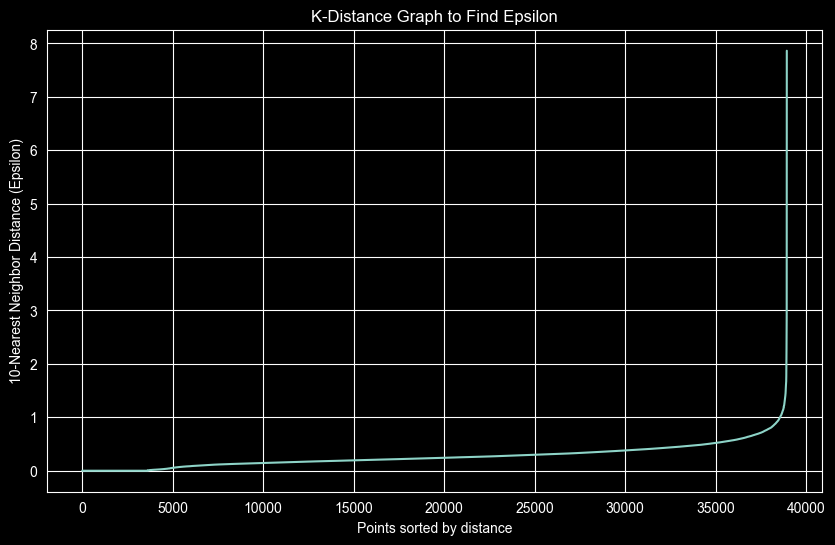

In [35]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
try:
    print("Reading File...")
    # this data is only 200 MB, so I can just read the whole thing. Using np.float16 to reduce memory usage.
    # Note, if your total word count is greater than 65536, change 'total_words':np.uint16 to 'total_words':np.uint32
    df = pd.read_json('data/rgub_data.json', lines=True, dtype={'cov_time':np.float32, 'cov_rating':np.float32, 'total_reviews':np.uint16, 'total_pictures':np.uint16, 'total_words':np.uint16, 'avg_words':np.float32, 'avg_pictures':np.float32})
    # keep user_id, total_pictures, total_reviews, total_words, cov_time, cov_rating
    print("Doing log transformations...")
    #doing log transformations to reduce the scale of the tail.
    df['log_reviews'] = np.log1p(df['total_reviews'], dtype=np.float32)
    df['log_pics'] = np.log1p(df['avg_pictures'], dtype=np.float32)
    df['log_words'] = np.log1p(df['avg_words'], dtype=np.float32)
    df.drop(columns=['max_pics', 'rev_with_pics', 'max_words', 'rev_with_words', 'avg_pictures', 'pics_percent','total_pictures', 'total_reviews', 'total_pictures', 'total_words'], inplace=True)
    features = df[['log_reviews', 'log_pics', 'log_words', 'cov_time', 'iod_rating']]

    # scale features
    print("Scaling features...")
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    # 1. Choose your k (min_samples)
    # Rule of thumb: min_samples = 2 * number of features
    k = 10
    # 2. Fit NearestNeighbors
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(X)
    distances, indices = nbrs.kneighbors(X)

    # 3. Sort the distances to the kth neighbor (the last column)
    distances = np.sort(distances[:, k-1], axis=0)

    # 4. Plot the distances
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.title('K-Distance Graph to Find Epsilon')
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{k}-Nearest Neighbor Distance (Epsilon)')
    plt.grid(True)
    plt.show()

except FileNotFoundError:
    print("File not found")



Epsilon of about 0.9. I will keep min_samples at the same level, even though we have 10x less records in this dataset. This is because min_samples is based on the number of dimensions.

Reading File...
Doing log transformations...
Scaling features...
Running DBSCAN...
Creating Scatter plot...
     log_reviews  log_pics  log_words  cov_time  iod_rating
PC1         0.63      0.35       0.52      0.42        0.19
PC2        -0.13     -0.12       0.37     -0.51        0.76
cluster
 0    29158
 1     9382
-1      369
 2       18
Name: count, dtype: int64


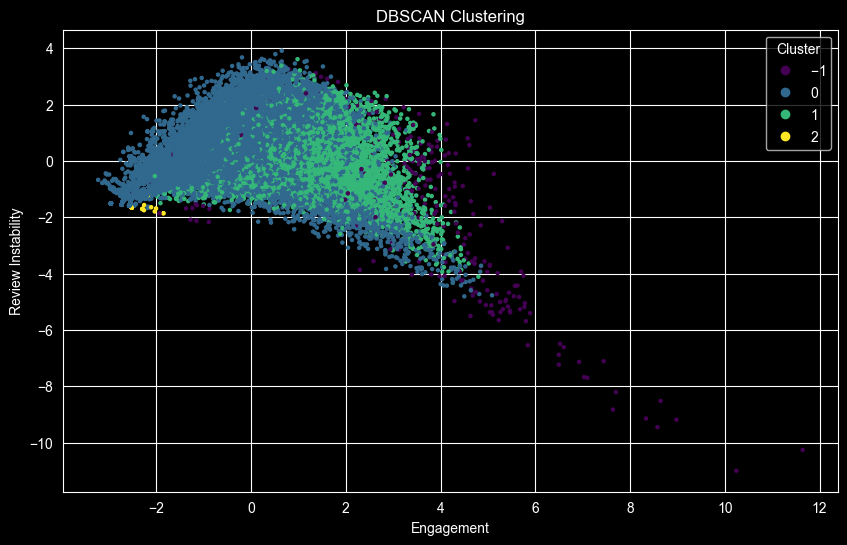

Running KMeans
Generating scatter plot...
     log_reviews  log_pics  log_words  cov_time  iod_rating
PC1         0.63      0.35       0.52      0.42        0.19
PC2        -0.13     -0.12       0.37     -0.51        0.76
k-cluster
2    16860
1     9421
3     6759
0     5887
Name: count, dtype: int64


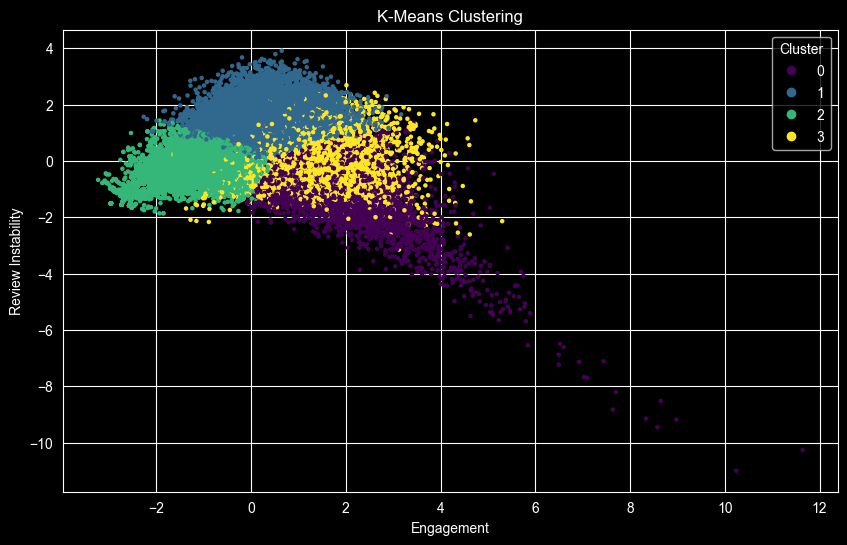

Running Isolation Forest...
The whole:
       words_percent  avg_words  cov_time  iod_rating  log_reviews  log_pics  \
count       38927.00   38927.00  38927.00    38927.00     38927.00  38927.00   
mean            0.67      33.02      1.29        0.33         2.58      0.28   
std             0.26      28.48      0.66        0.39         1.13      0.54   
min             0.00       0.00      0.01        0.00         0.69      0.00   
25%             0.50      13.00      0.92        0.01         1.79      0.00   
50%             0.69      27.36      1.25        0.18         2.20      0.00   
75%             0.88      45.67      1.39        0.54         3.37      0.00   
max             1.00     776.00     14.57        1.53         6.86      3.93   

       log_words  cluster  k-cluster  iforest_label  iforest_score  
count   38927.00 38927.00   38927.00       38927.00       38927.00  
mean        3.13     0.23       1.63           0.66           0.05  
std         1.04     0.45       0

In [36]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
try:
    print("Reading File...")
    # this data is only 200 MB, so I can just read the whole thing. Using np.float16 to reduce memory usage.
    # Note, if your total word count is greater than 65536, change 'total_words':np.uint16 to 'total_words':np.uint32
    df = pd.read_json('data/rgub_data.json', lines=True, dtype={'cov_time':np.float32, 'cov_rating':np.float32, 'total_reviews':np.uint16, 'total_pictures':np.uint16, 'total_words':np.uint16, 'avg_words':np.float32, 'avg_pictures':np.float32})
    # keep user_id, total_pictures, total_reviews, total_words, cov_time, cov_rating
    print("Doing log transformations...")
    #doing log transformations to reduce the scale of the tail.
    df['log_reviews'] = np.log1p(df['total_reviews'], dtype=np.float32)
    df['log_pics'] = np.log1p(df['avg_pictures'], dtype=np.float32)
    df['log_words'] = np.log1p(df['avg_words'], dtype=np.float32)
    df.drop(columns=['max_pics', 'rev_with_pics', 'max_words', 'rev_with_words', 'avg_pictures', 'pics_percent','total_pictures', 'total_reviews', 'total_pictures', 'total_words'], inplace=True)
    features = df[['log_reviews', 'log_pics', 'log_words', 'cov_time', 'iod_rating']]

    # scale features
    print("Scaling features...")
    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    # run DBSCAN on features, add cluster to df afterwards
    print("Running DBSCAN...")
    model = DBSCAN(eps=0.8, min_samples=10)
    labels = model.fit_predict(X)
    df['cluster'] = labels
    # create scatter plot
    print("Creating Scatter plot...")
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X)
    pc_df = pd.DataFrame(
        pca.components_,
        columns=features.columns,
        index=['PC1', 'PC2']
    )
    print(pc_df)
    print(df['cluster'].value_counts())
    plt.figure(figsize=(10, 6))
    plt.title("DBSCAN Clustering")
    scatter = plt.scatter(X2[:,0], X2[:,1], c=df['cluster'], s=5, cmap='viridis')
    legend = plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.xlabel("Engagement")
    plt.ylabel("Review Instability")

    plt.show()

    print("Running KMeans")
    # kmeans algorithm
    km = KMeans(n_clusters=4, init='k-means++', n_init=10, max_iter=300, random_state=42)
    # add cluster to df to compare with dbscan results
    km.fit(X)
    kl = km.labels_
    centroids = km.cluster_centers_
    sse = km.inertia_

    df['k-cluster'] = kl
    # reduce to 2 dimensions again.
    X2 = pca.fit_transform(X)
    pc_df = pd.DataFrame(
        pca.components_,
        columns=features.columns,
        index=['PC1', 'PC2']
    )
    print("Generating scatter plot...")
    print(pc_df)
    print(df['k-cluster'].value_counts())

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X2[:,0], X2[:,1], c=df['k-cluster'], s=5, cmap='viridis')

    plt.title("K-Means Clustering")
    legend = plt.legend(*scatter.legend_elements(), title="Cluster")
    # rename this after running once
    plt.xlabel("Engagement")
    plt.ylabel("Review Instability")
    plt.show()

    # run isolation forest algorithm
    print("Running Isolation Forest...")
    iso = IsolationForest()
    iso.fit(X)
    labels = iso.predict(X)
    scores = iso.decision_function(X)
    df["iforest_label"] = labels
    df["iforest_score"] = scores
    del iso
    del labels
    del scores

    print("The whole:")
    print(df.describe())


    print("\n\nExporting clusters into datasets")
    # separate clusters into their own dataset
    for i in df['cluster'].value_counts().index.tolist():
        df_temp = df[df['cluster'] == i]
        print("For cluster ",i)
        print(df_temp.describe())
        df_temp.to_json("data/business_dbscan"+str(i)+"_results.jsonl", orient='records', lines=True)
        # I decided to use .jsonl because Pycharm marked it as an error. I recognize that this error also applies to all the other .json files (including the original dataset. I, however, do not care because pandas json parser works anyway.)
    print("K Means:")
    for i in df['k-cluster'].value_counts().index.tolist():
        print("For cluster ",i)
        print(df[df['k-cluster']==i].describe())

    print("Naive Bayes: DBSCAN")
    # Naive Bayes
    #

    clf = GaussianNB()
    X = df[['log_reviews', 'log_pics', 'log_words', 'cov_time', 'iod_rating']]
    Y = df['cluster']

    X_train, X_test, Y_train, Y_test = train_test_split(
        X,
        Y,
        test_size=0.2,
        random_state=42
    )
    clf.fit(X_train, Y_train)
    accuracy = clf.score(X_test, Y_test)
    print("Accuracy:", accuracy)

    means = pd.DataFrame(
        clf.theta_,
        columns=['log_reviews', 'log_pics', 'log_words', 'cov_time', 'iod_rating']
    )

    means['cluster'] = clf.classes_
    print(means)

    print("Naive Bayes: KMeans")
    clf = GaussianNB()
    # X remains the same
    Y = df['k-cluster']
    X_train, X_test, Y_train, Y_test = train_test_split(
            X,
            Y,
            test_size=0.2,
            random_state=42
        )
    clf.fit(X_train, Y_train)
    accuracy = clf.score(X_test, Y_test)
    print("Accuracy:", accuracy)

    means = pd.DataFrame(
        clf.theta_,
        columns=['log_reviews', 'log_pics', 'log_words', 'cov_time', 'iod_rating']
    )

    means['k-cluster'] = clf.classes_
    print(means)
except FileNotFoundError:
    print("File not found")
except Exception as e:
    print(
        "Some other error occurred on line",
        e.__traceback__.tb_lineno,
        ":\n" + str(e)
    )


Doing log transformations...


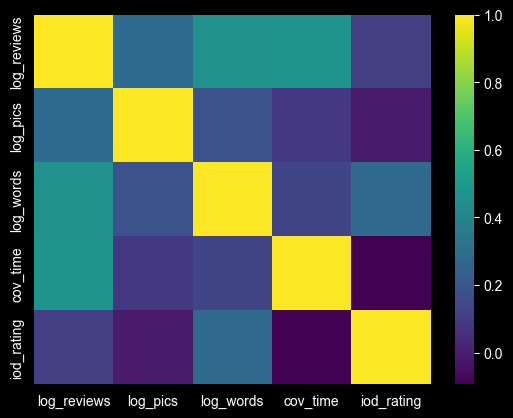

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
try:
    df = pd.read_json('data/rgub_data.json', lines=True, dtype={'cov_time':np.float32, 'cov_rating':np.float32, 'total_reviews':np.uint16, 'total_pictures':np.uint16, 'total_words':np.uint16, 'avg_words':np.float32, 'avg_pictures':np.float32, 'pics_percentage':np.float32, 'words_percentage':np.float32})
    # keep user_id, total_pictures, total_reviews, total_words, cov_time, cov_rating
    print("Doing log transformations...")
    #doing log transformations to reduce the scale of the tail.
    df['log_reviews'] = np.log1p(df['total_reviews'], dtype=np.float32)
    df['log_pics'] = np.log1p(df['avg_pictures'], dtype=np.float32)
    df['log_words'] = np.log1p(df['avg_words'], dtype=np.float32)
    df.drop(columns=['max_pics', 'rev_with_pics', 'max_words', 'rev_with_words', 'avg_pictures', 'total_pictures', 'total_reviews', 'total_pictures', 'total_words'], inplace=True)
    features = df[['log_reviews', 'log_pics', 'log_words', 'cov_time', 'iod_rating']]
    sns.heatmap(features.corr(), cmap='viridis')
    plt.show()
except FileNotFoundError:
    print("File not found")
except Exception as e:
    print(
        "Some other error occurred on line",
        e.__traceback__.tb_lineno,
        ":\n" + str(e)
    )

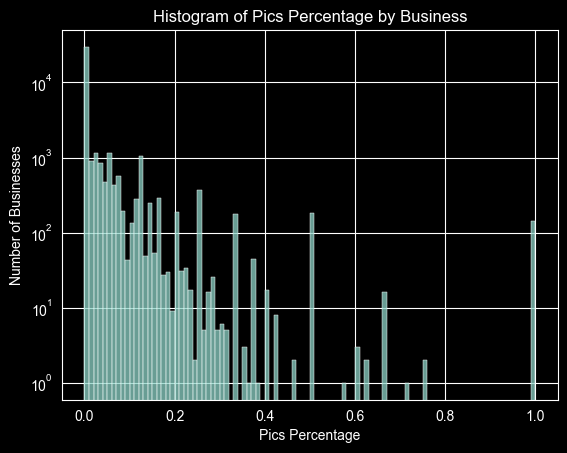

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_json('data/rgub_data.json', lines=True,)
    # we use bins = 51 since we now that we have 0-50 pictures in the reviews.
    plot = sns.histplot(df['pics_percent'], bins=100)
    plt.xlabel("Pics Percentage")
    plt.ylabel("Number of Businesses")
    plt.title("Histogram of Pics Percentage by Business")
    #using logarithmic scale because we would not be able to see anything.
    plot.set_yscale('log')
    plt.show()
except FileNotFoundError:
    print("File not found")